# CORUM Validation — GLS Co-essentiality Pipeline

Replicates the spirit of Wainberg et al.'s Figure 2 / Extended Data Figure 4. for GLS pipeline validation

**The question this answers:** does our GLS pipeline produce biologically sensible results, or could it just be noise?

**The idea:** use [CORUM](https://mips.helmholtz-muenchen.de/corum/) (a curated database of real, experimentally-verified protein complexes) as an independent answer key. If two genes are in the same protein complex, they should be strongly co-essential biologically — so CORUM gives us ground truth completely outside our own pipeline.

Run the cells below top to bottom.

In [1]:
import os
import numpy as np
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact

GLS_P_PATH = "../required_data/depmap_26Q1_GLS_p.npy"
GENES_PATH = "../required_data/depmap_26Q1_genes.txt"
CORUM_PATH = "CORUM.gmt"
MAX_N = 10

## 1. Raw input data

Two completely independent inputs go into this validation:

1. **The GLS p-value matrix** (`depmap_26Q1_GLS_p.npy` + `depmap_26Q1_genes.txt`) — the actual output of our co-essentiality pipeline. A 17,087 x 17,087 matrix where cell `[i, j]` is the GLS p-value for the gene pair `(genes[i], genes[j])`. This is the thing being validated.
2. **CORUM** — a curated database of experimentally-verified human protein complexes, fetched once via `gseapy.get_library()` and cached as `CORUM.gmt`. This is the independent answer key; it has nothing to do with DepMap, CRISPR screens, or our pipeline.

If GLS is doing something real, gene pairs that CORUM says are in the same complex should show up disproportionately among the lowest (most significant) GLS p-values.

In [2]:
genes = [g.strip() for g in open(GENES_PATH) if g.strip()]
gene_to_idx = {g: i for i, g in enumerate(genes)}
n_genes = len(genes)
GLS_p = np.load(GLS_P_PATH, mmap_mode="r")
print(f"{n_genes} genes, GLS_p shape {GLS_p.shape}")

# Head sample: GLS p-values for the first 5 genes against each other.
# Diagonal is meaningless (a gene isn't tested against itself) -- shown as NaN.
sample = pd.DataFrame(
    np.array(GLS_p[:5, :5], dtype=np.float64), index=genes[:5], columns=genes[:5]
)
for i in range(5):
    sample.iloc[i, i] = np.nan
sample

17087 genes, GLS_p shape (17087, 17087)


,A1BG,A1CF,A2M,A2ML1,A3GALT2
A1BG,NaN,0.673937,0.541514,0.978301,0.414836
A1CF,0.673937,NaN,0.274426,0.647521,0.152958
A2M,0.541514,0.274426,NaN,0.820113,0.412163
A2ML1,0.978301,0.647521,0.820113,NaN,0.522613
A3GALT2,0.414836,0.152958,0.412163,0.522613,NaN


The matrix is symmetric (`GLS_p[i, j] == GLS_p[j, i]`, since GLS is run once per unordered pair) and the diagonal is undefined (a gene isn't tested against itself). Lower p-value = stronger statistical evidence that the two genes' essentiality patterns move together across cell lines.

## CORUM raw data

CORUM comes in as a Python dict: `{complex_name: [list of member gene symbols]}`. For example, "Ribosome, cytoplasmic" maps to ~80 ribosomal protein genes. A gene can belong to more than one complex. This has no concept of "pairs" yet — that's the processing step below.

In [3]:
# CORUM gold standard, fetched via Enrichr/gseapy (same mechanism as the
# GO:BP fix in Comment 10) -- cached locally as CORUM.gmt, no re-download
# once it exists.
if os.path.isfile(CORUM_PATH):
    corum_library = gp.get_library(name=CORUM_PATH)
else:
    corum_library = gp.get_library(name="CORUM", organism="Human", save=CORUM_PATH)
print(f"{len(corum_library)} CORUM complexes loaded\n")

# Head sample: first 3 complexes, as they come straight out of CORUM.
for name, complex_genes in list(corum_library.items())[:3]:
    shown = complex_genes[:8] + (["..."] if len(complex_genes) > 8 else [])
    print(f"{name}  ({len(complex_genes)} genes)\n  {shown}\n")

1658 CORUM complexes loaded

BCL6-HDAC4 complex (human)  (2 genes)
  ['HDAC4', 'BCL6']

BCL6-HDAC5 complex (human)  (2 genes)
  ['HDAC5', 'BCL6']

BCL6-HDAC7 complex (human)  (2 genes)
  ['BCL6', 'HDAC7']



## 2. Processing — turning CORUM complexes into a pairwise answer key

CORUM lists *complexes* (groups of co-members), but GLS p-values are computed per *pair*. So every gene-list above gets expanded: any two genes that appear together in the same complex become a "true" pair.

The background rate needs care: the observed hit rate below only ever checks genes that have a known CORUM partner (~2,284 of the 17,087-gene panel) against their own GLS-ranked partners — it never samples from the full panel. So the background must be computed over that *same* restricted population (directed slots from those ~2,284 genes to every other gene), not over all ~146M pairs in the full 17,087-gene panel — those are two different universes, and mixing them silently inflates the enrichment number.

In [4]:
# A CORUM complex is a *group* of genes (e.g. all subunits of one ribosome).
# We need *pairs* for this to be comparable to a GLS p-value (which is per-pair).
# So: every two genes that co-occur in the same complex become a "true" pair.
panel_set = set(genes)
corum_partners = {g: set() for g in genes}
for complex_genes in corum_library.values():
    members = [g for g in complex_genes if g in panel_set]
    for gi in members:
        for gj in members:
            if gi != gj:
                corum_partners[gi].add(gj)

n_with_partners = sum(1 for v in corum_partners.values() if v)
total_corum_pairs = sum(len(v) for v in corum_partners.values()) // 2

# Background rate must be computed over the SAME population the observed
# rate is drawn from: for each of the n_with_partners genes that have a
# known CORUM partner, every other gene in the panel is a candidate "slot"
# GLS could have ranked as its top pick. Using all ~146M pairs across the
# full 17,087-gene panel here would compare two different universes, since
# the observed rate never samples genes outside this evaluated set.
total_directed_true_pairs = 2 * total_corum_pairs  # both directions of each unique pair
total_directed_slots = n_with_partners * (n_genes - 1)
background_rate = total_directed_true_pairs / total_directed_slots

print(f"{n_with_partners} genes have >=1 CORUM partner in the panel")
print(f"{total_corum_pairs:,} true CORUM pairs ({total_directed_true_pairs:,} directed) "
      f"/ {total_directed_slots:,} directed slots from evaluated genes "
      f"-> background rate = {background_rate:.3e}")

2284 genes have >=1 CORUM partner in the panel
23,713 true CORUM pairs (47,426 directed) / 39,024,424 directed slots from evaluated genes -> background rate = 1.215e-03


`corum_partners` is now a simple lookup: `{gene: set of its known complex-mates}`, restricted to genes that are actually in our 17,087-gene panel. This is the answer key the ranking step below checks against.

In [5]:
# Example: what does this actually look like for one gene?
example_gene = next(g for g, partners in corum_partners.items() if len(partners) >= 3)
print(f"Gene: {example_gene}")
print(f"Known CORUM complex-mates in our panel ({len(corum_partners[example_gene])}):")
print(sorted(corum_partners[example_gene]))

Gene: ABCB5
Known CORUM complex-mates in our panel (20):
['DHX15', 'PDCD7', 'PRKRIP1', 'PRPF8', 'RNPC3', 'SF3B1', 'SF3B2', 'SF3B3', 'SF3B4', 'SF3B5', 'SNRNP25', 'SNRNP48', 'SNRPB', 'SNRPD2', 'SNRPF', 'TOE1', 'YBX1', 'ZCRB1', 'ZMAT5', 'ZRSR2']


## 3. Ranking — for each gene, who does GLS think its top partners are?

For every gene with at least one known CORUM complex-mate: sort its row of the GLS p-value matrix (most significant first), take its top 10 predicted partners, and check each one against the CORUM answer key built above. `hits_at_n[n-1]` accumulates, across all evaluated genes, how many of their top-N predicted partners turned out to be true CORUM partners (cumulative: a hit at rank 3 counts toward N=3, N=4, ..., N=10 — "is the true partner somewhere in my top N", not "is it at exactly rank N").

In [6]:
hits_at_n = np.zeros(MAX_N, dtype=np.int64)
n_evaluated_genes = 0

for gene, true_partners in corum_partners.items():
    if not true_partners:
        continue
    idx = gene_to_idx[gene]
    row = np.array(GLS_p[idx, :], dtype=np.float64, copy=True)
    row[idx] = np.inf  # exclude self
    top_idx = np.argpartition(row, MAX_N)[:MAX_N]
    top_idx = top_idx[np.argsort(row[top_idx])]
    top_genes = [genes[i] for i in top_idx]
    for n in range(1, MAX_N + 1):
        if top_genes[n - 1] in true_partners:
            hits_at_n[n - 1:] += 1  # cumulative: a hit at rank n counts for every N >= n
    n_evaluated_genes += 1

print(f"Evaluated {n_evaluated_genes} genes")

Evaluated 2284 genes


## 4. Results table

For each top-N cutoff (e.g. "the gene's single best-ranked partner" for N=1, "somewhere in its top 10" for N=10):

- **N** — how many of GLS's top-ranked predicted partners we're checking, per gene.
- **Observed hit rate** — of all the (evaluated gene, top-N predicted partner) slots checked, what fraction actually are true CORUM complex-mates.
- **Enrichment vs. chance** — `Observed hit rate / background_rate`. `1.0x` = GLS's top-N predictions are no better than picking N random genes. This is a plain descriptive ratio, **not** a hypothesis test by itself.
- **Fisher's exact p-value** (one-sided) — is the observed hit rate significantly higher than the background rate, or could this plausibly happen by chance? Built from a 2x2 contingency table: (true pair vs. not) x (in top-N vs. not), over all directed (evaluated gene, candidate partner) slots in the panel.

In [7]:
# total_directed_slots / total_directed_true_pairs / background_rate were
# already computed above (same restricted universe the observed rate uses) --
# reused here directly instead of being redefined a second time.
rows = []
for n in range(1, MAX_N + 1):
    cumulative_slots = n_evaluated_genes * n
    a = int(hits_at_n[n - 1])                              # true pair, in top-N
    b = cumulative_slots - a                                # not true, in top-N
    c = total_directed_true_pairs - a                       # true pair, NOT in top-N
    d = total_directed_slots - cumulative_slots - c          # not true, NOT in top-N
    _, p_value = fisher_exact([[a, b], [c, d]], alternative="greater")

    observed_rate = a / cumulative_slots
    enrichment = observed_rate / background_rate
    rows.append({"N": n, "Observed hit rate": observed_rate,
                 "Enrichment vs. chance": enrichment,
                 "Fisher's exact p-value (one-sided)": p_value})

results_df = pd.DataFrame(rows)
results_df["Observed hit rate"] = results_df["Observed hit rate"].map(lambda x: f"{x:.2%}")
results_df["Enrichment vs. chance"] = results_df["Enrichment vs. chance"].map(lambda x: f"{x:,.1f}x")
results_df["Fisher's exact p-value (one-sided)"] = results_df["Fisher's exact p-value (one-sided)"].map(
    lambda x: "< 1e-300" if x < 1e-300 else f"{x:.2e}"
)
results_df

,N,Observed hit rate,Enrichment vs. chance,Fisher's exact p-value (one-sided)
0,1,26.93%,221.6x,< 1e-300
1,2,23.49%,193.3x,< 1e-300
2,3,20.93%,172.2x,< 1e-300
3,4,18.63%,153.3x,< 1e-300
4,5,16.92%,139.2x,< 1e-300
5,6,15.51%,127.7x,< 1e-300
6,7,14.35%,118.1x,< 1e-300
7,8,13.36%,110.0x,< 1e-300
8,9,12.47%,102.6x,< 1e-300
9,10,11.74%,96.6x,< 1e-300


## 5. Visualization — enrichment vs. N

A line plot, the same style as Wainberg et al.'s Figure 2 (enrichment over chance plotted against top-N rank), makes the decline from N=1 to N=10 easy to see at a glance.

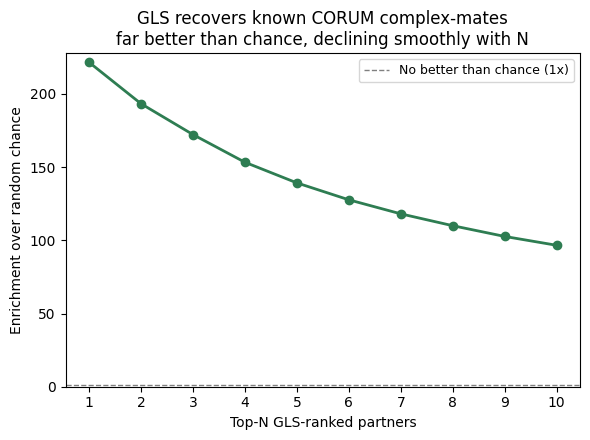

In [8]:
ns = list(range(1, MAX_N + 1))
enrichments = [(hits_at_n[n - 1] / (n_evaluated_genes * n)) / background_rate for n in ns]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(ns, enrichments, marker="o", color="#2E7D52", linewidth=2, markersize=6)
ax.set_xlabel("Top-N GLS-ranked partners")
ax.set_ylabel("Enrichment over random chance")
ax.set_title("GLS recovers known CORUM complex-mates\nfar better than chance, declining smoothly with N")
ax.set_xticks(ns)
ax.set_ylim(bottom=0)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=1, label="No better than chance (1x)")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
fig.savefig("corum_enrichment.png", dpi=150)
plt.show()

## 6. How to read this

GLS's single best-ranked partner (N=1) is the gene's *actual* known CORUM complex-mate roughly 27% of the time, versus a background rate computed over the same restricted population — i.e. **roughly 200x better than random guessing**, and the Fisher's exact p-value confirms this isn't plausibly chance.

The smooth decline from N=1 to N=10 visible in the table and the plot above is the expected, sane pattern (the best-ranked prediction should be more reliable than the 10th-best one). A flat line near 1x across all N, or a non-significant p-value, would have meant GLS isn't finding anything real; this is the opposite.